# Блокнот с экспериментами и заметками

Много экспериментов просто **не записалось**, т.к. думал оставить этот блокнот как черновик, ну и не понимал насколько интересной окажется задача, которую я перед собой поставил.

In [2]:
from cube import Cubik2

import random

import time

import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np

import matplotlib.pyplot as plt

In [3]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("xpu" if torch.xpu.is_available() else "cpu")

In [4]:
moves = ["R","L","U","D","F","B",
        "R'", "L'","U'","D'","F'","B'"]

n_moves = len(moves)

# Шифруемся

In [5]:
def encode_state(c):
    corners = torch.tensor(c.corners, dtype=torch.long)
    rotations = torch.tensor(c.rotation, dtype=torch.long)

    corners = F.one_hot(corners, num_classes=8).flatten()
    rotations = F.one_hot(rotations, num_classes=3).flatten()

    x = torch.cat((corners, rotations)).float()
    return x

In [6]:
state_size = encode_state(Cubik2()).size()[0]

*Забавный факт: до определенного момента строчки выше не было и в DQN на месте state_size стояло число, которое я вычислял руками.*

## Структура модели

На данный момент исследований лучше всего себя показала модель с 3 скрытыми слоями и размерностями ниже. Дальше расширяться не приносило больших успехов, поэтому я остановлюсь на этом.

In [7]:
class DQN(nn.Module):
    def __init__(self, state_size=state_size, n_moves=n_moves):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_size, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, n_moves)
        )

    def forward(self, x):
        return self.net(x)

## Случайности

Иногда модель должна делать **случайный ход**, а не тот который она считает лучшим, чтобы исследовать и учиться понимать важность разных действий.

Также вероятность случайного хода должна **меняться** в зависимости от шага обучения. Тут очень большое поле для экспериментов. Об этом чуть дальше.

In [8]:
def choose_move(model, state, eps): 
    # выбор хода с вероятностью eps определен рандомом
    if random.random() < eps:
        return random.randrange(n_moves)

    state = state.to(device)

    with torch.no_grad():
        q_values = model(state)

    move = q_values.argmax().item()

    return move

## Шаг обучения

Тут я особо не трогал в процессе экспериментов, важно лишь понимать, что рассчет целевого значения имеет вид

$$
q_{\text{target}}=r_t+\gamma(1-d_t)\max_a Q_{\text{target network}}(s_{t+1}, a)
$$

Где $r_t$ - награда за текущий шаг, $d_t$ - успешность сборки кубика, 
$Q_{\text{target network}}$ - вторая модель, которая обновляется с задержкой,
$\gamma$ - коэффицент, чтобы модель не уходила в бесконечность (чем дальше уходим, тем больше умножаем на $\gamma < 1$ и стремимся к 0)

In [9]:
def train_step(
    model,
    target_model,
    optimizer,
    replay_buffer,
    batch_size=128,
    gamma=0.99
):
    if len(replay_buffer) < batch_size:
        return None

    batch = random.sample(replay_buffer,batch_size)

    states = torch.stack([x[0] for x in batch]).to(device)
    actions = torch.tensor([x[1] for x in batch], dtype=torch.long, device=device)
    rewards = torch.tensor([x[2] for x in batch], dtype=torch.float32, device=device)
    next_states = torch.stack([x[3] for x in batch]).to(device)
    dones = torch.tensor([x[4] for x in batch], dtype=torch.float32, device=device)

    q_values = model(states)

    current_q = q_values.gather(1,actions.unsqueeze(1)).squeeze(1)
    
    with torch.no_grad():
        next_q_values = target_model(next_states)
        max_next_q = next_q_values.max(dim=1).values
        target_q = (rewards + gamma * max_next_q * (1 - dones))
        
    loss = torch.nn.functional.smooth_l1_loss(current_q, target_q)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

## Один эпизод из жизни модели

Процесс одного эпизода выглядит так: 

    1. Разбираем кубик
    2. Запускаем цикл сборки на max_steps
    3. Если модель собрала кубик, то очень хорошо награждаем
    4. Если модель не собрала кубик, то вычитаем немного очков
    5. Записываем в буффер начальное состояние, ход, награду, полученное состояние и успешность сборки
    6. Обучаем модель и если собрали кубик, то выходим из цикла
    
Аналогично с шагом обучения, я не лез менять первоначальные параметры. 

In [10]:
def run_episode(
    cubik,
    model,
    target_model,
    optimizer,
    replay_buffer,
    scramble_depth,
    eps,
    max_steps
):

    cubik = Cubik2()

    cubik.scramble(n=scramble_depth)

    loss = None

    for step in range(max_steps):
        state = encode_state(cubik)

        move_idx = choose_move(model, state, eps)
        move = moves[move_idx]
        cubik.move(move)
        
        next_state = encode_state(cubik)
        
        solved = cubik.isSolved()

        if solved:
            reward = 100.0
        else:
            reward = -1.0

        replay_buffer.append(
            (
                state,
                move_idx,
                reward,
                next_state,
                solved
            )
        )

        loss = train_step(model, target_model, optimizer, replay_buffer)
        if solved:
            return True, step + 1, loss

    return False, max_steps, loss

В отдельную функцию я вынес "генератор" глубины. Он должен давать с заданными вероятностями модельке либо текущую глубину, либо глубину меньше, чтобы модель не забывала как решать более простые кубики.

In [11]:
def pick_depth(current_depth):
    if current_depth == 1:
        return 1

    r = random.random()

    if r < 0.70: # 70% что запустимся на текущей глубине
        return current_depth

    if r < 0.90: # 20% что запустимся на прошлой глубине
        return current_depth - 1

    return random.randint(1, current_depth - 1)

## Самое интересное

После подготовки пора запускать саму модель. Так как много экспериментов я просто потерял из-за того, что не вел записи, я решил вынести все в отдельную функцию, запускать ее с разными параметрами и проверять результаты.

Про эту функцию ниже.

In [12]:
def run_experiment(n_episodes, max_steps, learning_rate, update_step, success_threshold, eps_duration=500, eps_rate=1.5):
    # засекаем время работы
    start_time = time.time()
    # параметры
    buffer_max_size = 500_000

    # создаем модель и таргет модель
    model = DQN().to(device)
    
    target_model = DQN().to(device)
    target_model.load_state_dict(model.state_dict())
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    replay_buffer = []
    scramble_depth = 1
    recent_results = []
    global_step = 0
    
    cubik = Cubik2()
    
    success_rate_stats = []
    depth_start_episode = [0]
    
    target_depth = 20
    
    print(
                "Максимум шагов:", max_steps, "\n",
                "Learning rate:", learning_rate, "\n",
                "Интервал обновления:", update_step, "\n",
                "Макс. размер буффера:", buffer_max_size, "\n",
                "Целевая глубина:", target_depth
            )
    
    local_episode = 0
    
    for episode in range(n_episodes):
        if local_episode < eps_duration:
            eps = (1-(local_episode/eps_duration))/eps_rate
        else:
            eps = 0.05
    
        episode_depth = pick_depth(scramble_depth)
        
        solved, steps, loss = run_episode(
            cubik,
            model,
            target_model,
            optimizer,
            replay_buffer,
            episode_depth,
            eps,
            max_steps
        )
    
        global_step += steps
        local_episode += 1
    
        recent_results.append(int(solved))
    
        if len(recent_results) > 200:
            recent_results.pop(0)
    
        if (global_step % update_step < steps): # обновляемся ~ каждые update_step шагов (не придумал как лучше считать)
            elapsed_time = time.time() - start_time
            print(f"Обновляем таргет, прошло: {episode}/{n_episodes} эпизодов, {elapsed_time:.2f} сек")
            target_model.load_state_dict(model.state_dict())
    
        if len(replay_buffer) > buffer_max_size + 5000:
            replay_buffer = replay_buffer[-buffer_max_size:]
    

        success_rate = (sum(recent_results)/max(1, len(recent_results)))
        
        if (len(recent_results) == 200 and sum(recent_results)/200 > success_threshold):
            scramble_depth += 1
            recent_results.clear()
            local_episode = 0
            depth_start_episode.append(episode)
            if scramble_depth == target_depth+1:
                print("Достигнута целевая глубина:", target_depth)
                break
        
    
        if episode % 100 == 0:
            success_rate_stats.append([success_rate,eps,scramble_depth,len(replay_buffer)])
            # раньше отслеживал все так
            # print(
            #     "Эпизод:", episode,
            #     "Глубина:", scramble_depth,
            #     "Успешность:", round(success_rate, 2),
            #     "Случайность:", round(eps, 2),
            #     "Буфер опыта:", len(replay_buffer),
            #     "Loss:", loss,
            # )
    
    elapsed_time = time.time() - start_time
    print(f"Время обучения: {elapsed_time:.2f} сек, достигнутая глубина: {scramble_depth}")

    return {
        "model": model,
        "target_model": target_model,
        "replay_buffer": replay_buffer,
        "final_depth": scramble_depth,
        "stats": success_rate_stats,
        "depth_start_episode": depth_start_episode,
    }

Каждые 100 эпиозодов собираю интересующую меня статистику: коэффицент успешности, вероятность случайного хода, глубину, размер буфера. А также на каждом переходе глубины храню эпизод перехода. 

Про **изменение вероятности**: я пока **не придумал окончательный вариант** и эксперементирую с этим.

## Про run_experiment

Я решил сделать вывод в словарик и собирать все что только можно собрать. На параметры же принимать то, что чаще всего менял ранее в экспериметах:

```n_episodes``` - количество эпизодов

```max_steps``` - максимум допустимых шагов (кто-то посчитал, что кубик 2х2 можно собрать за 14 ходов, я верю этому человеку, но не до конца, поэтому оставляю 20 с возможностью изменить в дальнейшем, если меня не устроит скорость обучения)

```learning_rate``` - скорость обучения (размер шага изменения весов)

```update_step``` - через сколько шагов обновляем таргет (=поворотов кубика, зависит от ```max_steps```)

```success_threshold``` - условие перехода на следующую глубину (модель должна решать текущую глубину не хуже чем этот порог)

## Перед запуском: важные замечания которые я выделил для себя ранее:

* Первая гипотеза: **ограничить число шагов** хотя-бы **30**, иначе модель не продвигается дальше 2 глубины.
* Вторая гипотеза: порог перехода должен быть не слишком большим, иначе обучение затягивается без явных улучшений
* Третья гипотеза:  скорость обучения и шаги обновления - **ключевые параметры** для исследований.

Кстати все-таки пришлось прописать **обратные ходы**, т.к. иначе глубина 1 не имеет смысла, ибо требуется минимум 3 хода. (Если есть R и нет R', то единственный способ сделать R' это RRR)

# Запускаем эксперименты

Так как мое железо достаточно слабое, для меня очень важным показателем является эффективность обучения модели. Если есть возможность достичь результата быстрее, то лучше ей воспользоваться. **Показателем результата обучения** я считаю глубину, достигнутую моделью за **10,000** эпизодов.

Первые эксперименты я делаю произвольно на 1,000 эпизодов, чтобы подобрать оптимальные параметры начиная с быстрых экспериментов.

In [54]:
result_first = run_experiment(
    n_episodes=1000,
    max_steps=20,
    learning_rate=1e-4,
    update_step=800*20,
    success_threshold=0.85,
)

Максимум шагов: 20 
 Learning rate: 0.0001 
 Интервал обновления: 16000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Время обучения: 136.86 сек, достигнутая глубина: 2


## Визуализации

Далее я буду визуализировать график изменения ```success_rate``` в зависимости от пройденных эпизодов. Еще я добавил на фон график ```eps```, т.к. это важный показатель влияющий на success_rate. Для удобства вынесем это в отдельную функцию.

In [13]:
def visualize(result, size=(6, 3), title="Успешность в зависимости от количества эпизодов", success_threshold=-1, legend=True):
    episodes = [i*100 for i in range(0,len(result['stats']))]
    success_rates = [x[0] for x in result['stats']]
    epsilons = [x[1] for x in result['stats']]
    plt.figure(figsize=size)

    plt.plot(episodes, success_rates, marker="o", label="Успешность")
    plt.plot(episodes, epsilons, linestyle="--", alpha=0.35, label="Epsilon")
    
    for episode in result['depth_start_episode']:
        plt.axvline(x=episode, linestyle="--", alpha=0.6)
    if success_threshold != -1:
        plt.axhline(y=success_threshold, linestyle="--", alpha=0.5, label="Порог перехода")
    
    plt.xlabel("Эпизод")
    plt.ylabel("Успешность")
    plt.title(title)
    
    plt.grid(True)
    if legend:
        plt.legend()
    
    plt.show()

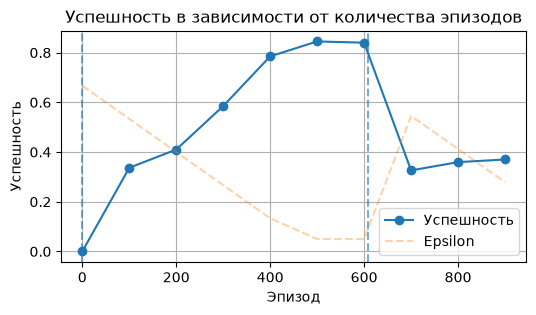

In [56]:
visualize(result_first)

Сейчас мы достигаем глубины 2 примерно к 600 эпизоду. Попробуем запуститься дальше. 

*P.S. С названиями результатов забавно вышло*

In [61]:
result_first_all_episodes = run_experiment(
    n_episodes=10000,
    max_steps=20,
    learning_rate=1e-4,
    update_step=800*20,
    success_threshold=0.85,
)

Максимум шагов: 20 
 Learning rate: 0.0001 
 Интервал обновления: 16000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Обновляем таргет, прошло: 1598/10000 эпизодов, 224.87 сек
Обновляем таргет, прошло: 3751/10000 эпизодов, 472.98 сек
Обновляем таргет, прошло: 5630/10000 эпизодов, 735.37 сек
Обновляем таргет, прошло: 7750/10000 эпизодов, 1012.31 сек
Время обучения: 1314.21 сек, достигнутая глубина: 3


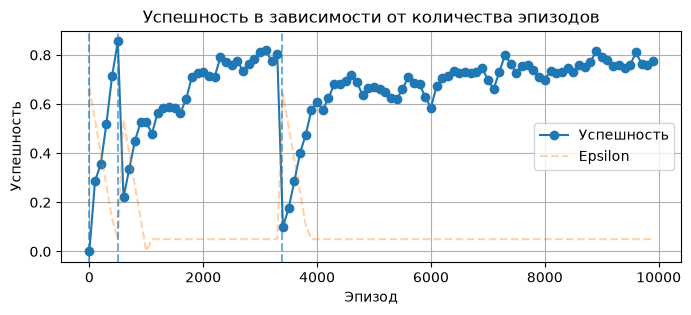

In [104]:
visualize(result_first_all_episodes, size=(8,3))

Мы достигли 3 глубины, но что это дает на самом деле? Насколько эффективна модель, которая получилась сейчас?

## Новая метрика

Хотелось бы оценить **качество обученной модели**, чтобы понять имеет ли смысл **дальнейшее обучение** или мы уже довольны результатом. Для этого нужны какие-то понятные метрики. 

Первая такая метрика - **количество решеннных кубиков за <N ходов**. Так как в процессе обучения модель была сильно урезана в количестве ходов, стоит попробовать дать ей большее число и посмотреть, что получится на выходе. В среднем я решаю кубик примерно за 30-40 ходов, но модель не знает алгоритмов, поэтому дадим ей в 10 раз больше.

In [14]:
def trySolve(model, N):
    model = model.to(device)
    cubik = Cubik2()
    cubik.scramble()
    for i in range(N):
        state = encode_state(cubik)
        state = state.to(device)

        with torch.no_grad():
            q_values = model(state)
    
        move_idx = q_values.argmax().item()
        cubik.move(moves[move_idx])
        
        if cubik.isSolved():
            return i+1

    return -1

In [15]:
def countSolves(model, N=400, n=50):
    res = []
    for _ in range(n):
        res.append(trySolve(model, N))
    cnt_solved = len(res) - res.count(-1)
    return cnt_solved, res

In [ ]:
cnt_solved_first = countSolves(result_first_all_episodes["model"])

In [82]:
print(cnt_solved_first[0])

0


Вторая метрика - **медианное число ходов на решение кубика**. Если модель умеет решать кубик в N ходов, то это еще не значит, что она будет делать это всегда за N, поэтому нужно взять медиану по количеству ходов на решение.

In [16]:
def countMedianPerSolve(model, N=400, n=50):
    _, a = countSolves(model, N, n)
    a = [x for x in a if x != -1]
    if len(a) > 0:
        a.sort()
        return a[len(a)//2]
    else:
        return -1

In [81]:
median_per_solve_first = countMedianPerSolve(result_first_all_episodes["model"])

In [83]:
print(median_per_solve_first)

-1


И в идеале иметь **общую функцию** для обеих метрик.

In [17]:
def getModelStats(model, N=400, n=50):
    """Возвращает количество решеннных кубиков за <N ходов и медианное число ходов на решение кубика"""
    cnt_solves, a = countSolves(model, N, n)
    if cnt_solves == 0:
        return 0, -1
    a = [x for x in a if x != -1]
    return len(a), a[len(a)//2]

In [85]:
print(getModelStats(result_first_all_episodes["model"]))

(0, -1)


Пока наша модель вообще не справляется с решением кубиков. Попробуем дать ей больше ходов в процессе обучения и немного увеличить порог перехода на следующую глубину.

**Текущая гипотеза:** мы слишком ограничили модель в ходах, так что она плохо изучает все возможные варианты, а также слишком быстро переходит на слеудющую глубину, не разобравшись с предыдущей

Попробуем смоделировать пару мини-экспериментов и сравнить с изначальным результатом. На мини-экспериментах будет лучше видно влияние количества ходов, а на больших - влияние порога перехода.

In [87]:
result_second = run_experiment(
    n_episodes=1000,
    max_steps=30,
    learning_rate=1e-4,
    update_step=800*20,
    success_threshold=0.9,
)

Максимум шагов: 30 
 Learning rate: 0.0001 
 Интервал обновления: 16000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Время обучения: 178.46 сек, достигнутая глубина: 1


In [106]:
result_third = run_experiment(
    n_episodes=1000,
    max_steps=40,
    learning_rate=1e-4,
    update_step=800*20,
    success_threshold=0.9,
)

Максимум шагов: 40 
 Learning rate: 0.0001 
 Интервал обновления: 16000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Обновляем таргет, прошло: 827/1000 эпизодов, 225.44 сек
Время обучения: 274.86 сек, достигнутая глубина: 2


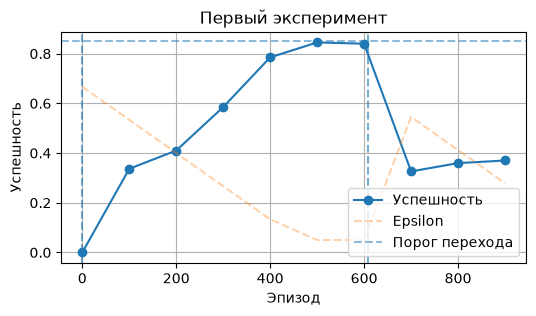

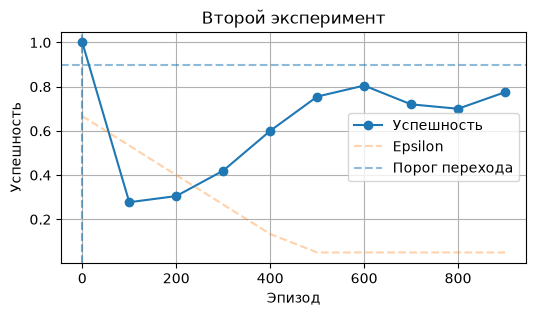

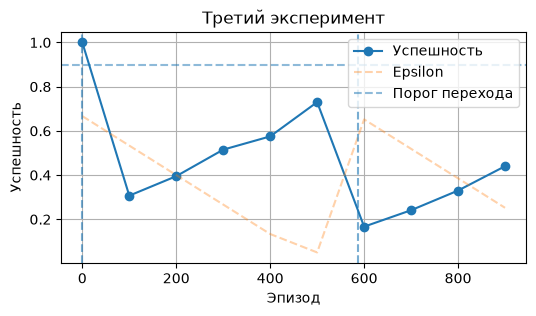

In [108]:
visualize(result_first, title="Первый эксперимент", success_threshold=0.85)
visualize(result_second, title="Второй эксперимент", success_threshold=0.9)
visualize(result_third, title="Третий эксперимент", success_threshold=0.9)

Пока все еще непонятно действительно ли большая свобода в ходах дает лучший результат, но по мини-экспериментам можно подвергнуть сомнению **первую гипотезу**. Поэтому сделаем проверку на дистанции.

In [109]:
result_second_all_episodes = run_experiment(
    n_episodes=10000,
    max_steps=30,
    learning_rate=1e-4,
    update_step=800*20,
    success_threshold=0.9,
)

Максимум шагов: 30 
 Learning rate: 0.0001 
 Интервал обновления: 16000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Обновляем таргет, прошло: 1142/10000 эпизодов, 226.70 сек
Обновляем таргет, прошло: 2441/10000 эпизодов, 454.53 сек
Обновляем таргет, прошло: 4215/10000 эпизодов, 688.69 сек
Обновляем таргет, прошло: 6297/10000 эпизодов, 936.39 сек
Обновляем таргет, прошло: 7537/10000 эпизодов, 1204.37 сек
Обновляем таргет, прошло: 9080/10000 эпизодов, 1472.14 сек
Время обучения: 1615.59 сек, достигнутая глубина: 3


In [110]:
result_third_all_episodes = run_experiment(
    n_episodes=10000,
    max_steps=40,
    learning_rate=1e-4,
    update_step=800*20,
    success_threshold=0.9,
)

Максимум шагов: 40 
 Learning rate: 0.0001 
 Интервал обновления: 16000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Обновляем таргет, прошло: 901/10000 эпизодов, 218.91 сек
Обновляем таргет, прошло: 2163/10000 эпизодов, 436.49 сек
Обновляем таргет, прошло: 3674/10000 эпизодов, 660.88 сек
Обновляем таргет, прошло: 4686/10000 эпизодов, 935.77 сек
Обновляем таргет, прошло: 6050/10000 эпизодов, 1222.10 сек
Обновляем таргет, прошло: 7813/10000 эпизодов, 1511.87 сек
Обновляем таргет, прошло: 9666/10000 эпизодов, 1798.97 сек
Время обучения: 1854.62 сек, достигнутая глубина: 3


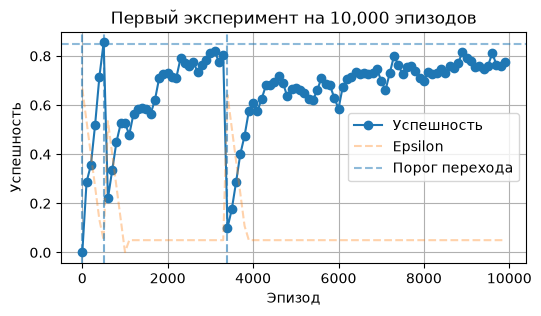

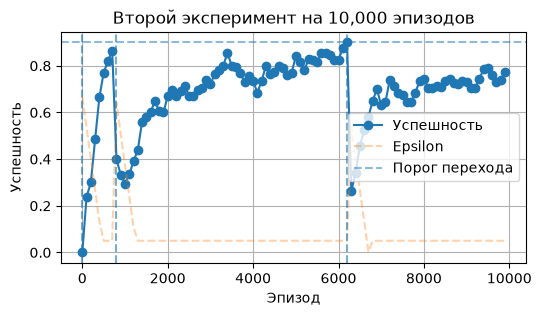

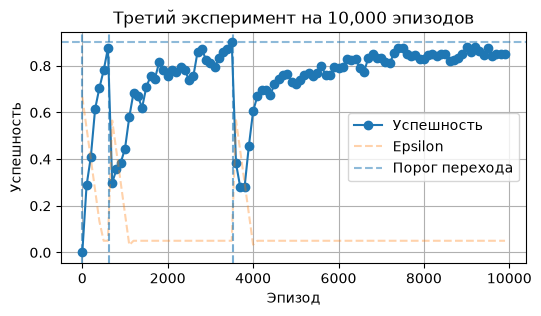

In [111]:
visualize(result_first_all_episodes, title="Первый эксперимент на 10,000 эпизодов", success_threshold=0.85)
visualize(result_second_all_episodes, title="Второй эксперимент на 10,000 эпизодов", success_threshold=0.9)
visualize(result_third_all_episodes, title="Третий эксперимент на 10,000 эпизодов", success_threshold=0.9)

Теперь больше данных, чтобы считать, что первая гипотеза не является верной. Несмотря на то, что в первом и третьем эксперименте графики выглядят схоже, в последнем модель быстрее повысила свою точность после снижения случайности и держала ее на высоком уровне. Когда мы дали модели возможность ходить дальше, она смогла раньше достигнуть 3 глубины, а также лучше приблизилась к порогу перехода. Отсюда **новая гипотеза:** нужно расширять пространство исследования.

Чтобы расширить пространство исследования можно не только добавлять возможность делать больше ходов, но и делать промежуток с повышенной вероятностью случайного хода более длинным.

Для этого я ввел две новые переменные: ```eps_duration``` и ```eps_rate```. Первая отвечает за длительность (в эпизодах) промежутка где ```eps``` идет на понижение, а вторая за скорость этого понижения (а также начальное значение). Изначально они были заданы как 500 и 1.5, но я вынес их отдельно и мы можем задать им произвольное значение.

Попробуем опускать ```eps``` плавно, начиная с 1 в течение 1000 эпизодов и посмотрим на результат. Но на этот раз запустимся на 2000 эпизодов. За основу беру третий эксперимент

In [114]:
result_fourth = run_experiment(
    n_episodes=2000,
    max_steps=40,
    learning_rate=1e-4,
    update_step=800*20,
    success_threshold=0.9,
    eps_duration=1000,
    eps_rate=1
)

Максимум шагов: 40 
 Learning rate: 0.0001 
 Интервал обновления: 16000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Обновляем таргет, прошло: 953/2000 эпизодов, 282.24 сек
Обновляем таргет, прошло: 1550/2000 эпизодов, 499.25 сек
Время обучения: 571.36 сек, достигнутая глубина: 2


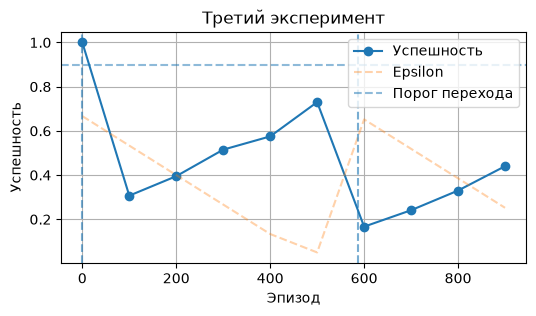

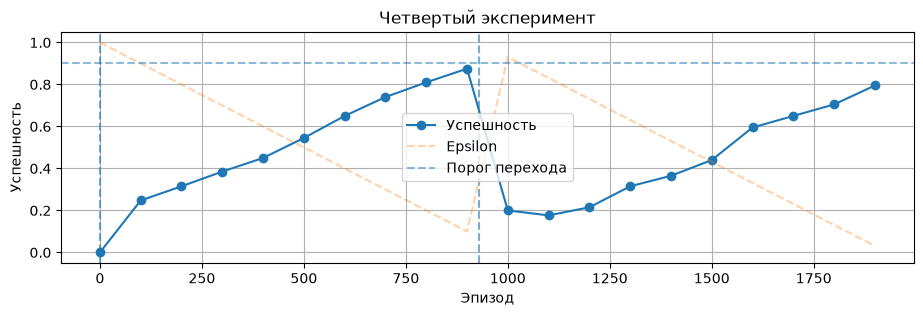

In [127]:
visualize(result_third, title="Третий эксперимент", success_threshold=0.9)
visualize(result_fourth, title="Четвертый эксперимент", success_threshold=0.9,size=(11,3))

Пока графики выглядят достаточно схоже. В четвертом эксперементе переход произошел позже, т.к. мы растянули повышенную вероятность случайного хода.

Попробуем запуститься на 5000 эпизодов.

In [121]:
result_fourth_5000 = run_experiment(
    n_episodes=5000,
    max_steps=40,
    learning_rate=1e-4,
    update_step=800*20,
    success_threshold=0.9,
    eps_duration=1000,
    eps_rate=1
)

Максимум шагов: 40 
 Learning rate: 0.0001 
 Интервал обновления: 16000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Обновляем таргет, прошло: 941/5000 эпизодов, 226.79 сек
Обновляем таргет, прошло: 1491/5000 эпизодов, 455.41 сек
Обновляем таргет, прошло: 2458/5000 эпизодов, 689.26 сек
Обновляем таргет, прошло: 3333/5000 эпизодов, 937.77 сек
Обновляем таргет, прошло: 4789/5000 эпизодов, 1200.23 сек
Время обучения: 1326.83 сек, достигнутая глубина: 4


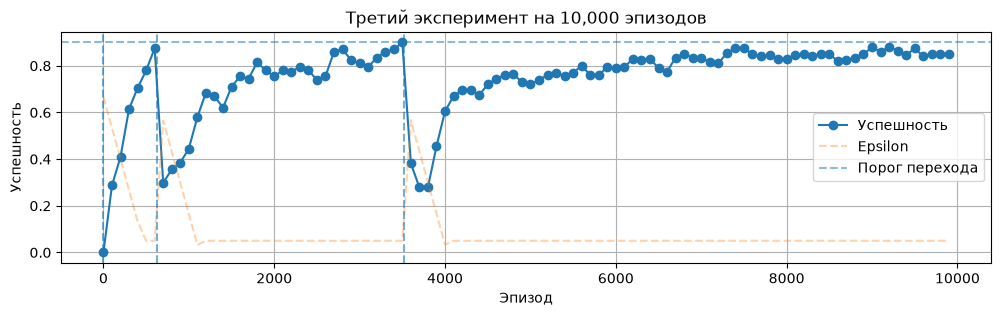

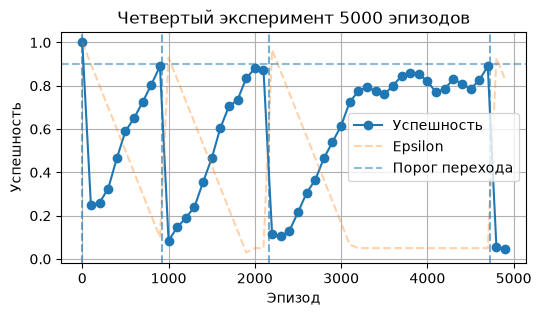

In [124]:
visualize(result_third_all_episodes, title="Третий эксперимент на 10,000 эпизодов", success_threshold=0.9,size=(12,3))
visualize(result_fourth_5000, title="Четвертый эксперимент 5000 эпизодов", success_threshold=0.9)

Мы пробили планку глубины! И за вдвое меньшее число эпизодов.

Проверим может ли она уже справляться с задачей.

In [138]:
result_fourth_5000_stats = list(getModelStats(result_fourth_5000["model"]))

In [139]:
print(result_fourth_5000_stats)

[0, -1]


**Как и ожидалось**, уметь решать что-то простое, где требуется 2-3 хода не означает возможность решить сложные разобранные кубики.

Каждый раз мы кормим модели разобранный кубик на фиксированную глубину и в процессе она делает глупые ходы, попадая во всевозможные комбинации и делая выводы о **ценности ходов**. Но иногда **ходить слишком далеко вглубину бесполезно** - мы тратим ресурс обучения на то, чтобы модель поняла, что уже **безвыходная ситуация приводит к более безвыходным**. На малых шагах это наиболее явно (допустим нужно сделать 1 ход, а мы сделали 5 шагов от собранного кубика, тогда следующие шаги должны попасть точно в цель, чтобы собрать кубик, а вероятность того, что модель знает как это сделать очень низкая). Конечно, можно надеяться, что за 100 ходов она случайно достигнет цели, но такая вероятность крайне низкая. Тогда может достаточно растягивать ```eps_duration```, но не пытаться делать множество ходов в поисках собранного кубика?

В пятом эксперименте я снизил ```max_steps``` до 20 и растянул eps_duration до 1500. Также я запускаю сразу 5000 эпизодов, т.к. первые 1000 и 2000 будут менее понятны относительно прошлых экспериментов из-за высокого ```eps```.

In [151]:
result_fifth = run_experiment(
    n_episodes=5000,
    max_steps=20,
    learning_rate=1e-4,
    update_step=800*20,
    success_threshold=0.9,
    eps_duration=1500,
    eps_rate=1
)

Максимум шагов: 20 
 Learning rate: 0.0001 
 Интервал обновления: 16000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Обновляем таргет, прошло: 1537/5000 эпизодов, 214.84 сек
Обновляем таргет, прошло: 3223/5000 эпизодов, 435.69 сек
Обновляем таргет, прошло: 4398/5000 эпизодов, 680.20 сек
Время обучения: 748.39 сек, достигнутая глубина: 3


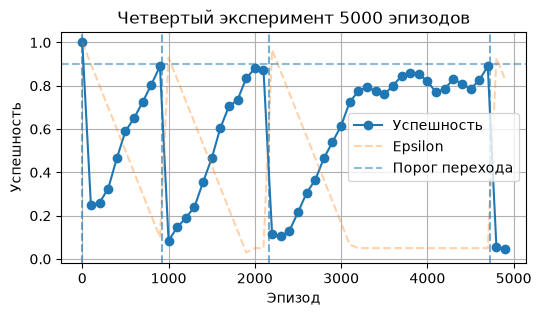

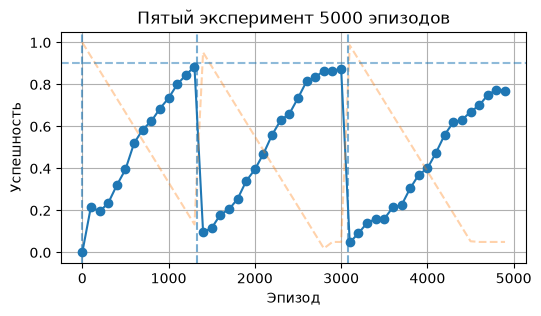

In [152]:
visualize(result_fourth_5000, title="Четвертый эксперимент 5000 эпизодов", success_threshold=0.9)
visualize(result_fifth, title="Пятый эксперимент 5000 эпизодов", success_threshold=0.9, legend=False)

Выше я говорил, что ```update_step``` зависит от ```max_steps```, но в какой-то момент забыл про него. Теперь когда я снова понизил ```max_steps```, стоит **повторить эксперимент с предыдущими зависимостями**, а именно - возникшая по невнимательности ```updatestep = 800*maxsteps/2```. Возможно, это даст явный результат и **ключевую переменную**, а заодно подтвердит или опровергнет выше выдвинутую **гипотезу 3**.

А пока все что можно сказать **про графики выше** - мы растянули линию успешности, что впринципе было **ожидаемо**.

In [153]:
result_sixth = run_experiment(
    n_episodes=5000,
    max_steps=20,
    learning_rate=1e-4,
    update_step=800*10,
    success_threshold=0.9,
    eps_duration=1500,
    eps_rate=1
)

Максимум шагов: 20 
 Learning rate: 0.0001 
 Интервал обновления: 8000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Обновляем таргет, прошло: 580/5000 эпизодов, 103.18 сек
Обновляем таргет, прошло: 1522/5000 эпизодов, 211.43 сек
Обновляем таргет, прошло: 2131/5000 эпизодов, 329.60 сек
Обновляем таргет, прошло: 3285/5000 эпизодов, 455.05 сек
Обновляем таргет, прошло: 3763/5000 эпизодов, 574.10 сек
Обновляем таргет, прошло: 4509/5000 эпизодов, 711.16 сек
Время обучения: 762.32 сек, достигнутая глубина: 3


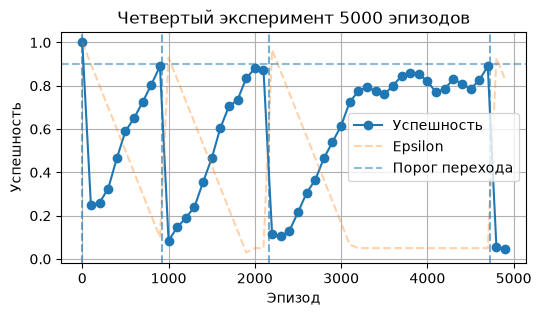

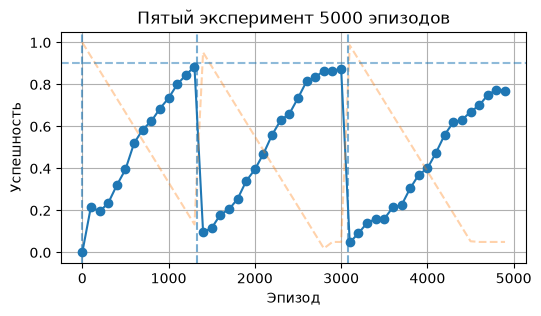

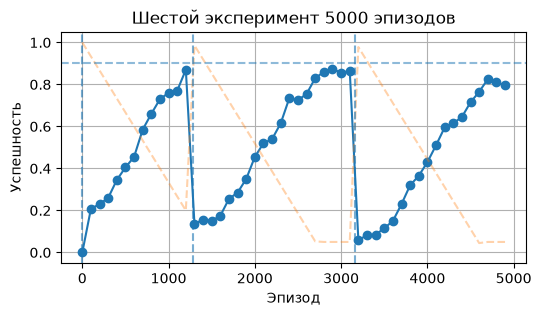

In [154]:
visualize(result_fourth_5000, title="Четвертый эксперимент 5000 эпизодов", success_threshold=0.9)
visualize(result_fifth, title="Пятый эксперимент 5000 эпизодов", success_threshold=0.9, legend=False)
visualize(result_sixth, title="Шестой эксперимент 5000 эпизодов", success_threshold=0.9, legend=False)

В пятом эксперименте более линейный рост и **меньшее количество скачков**, хотя шестой эксперимент, кажется, легко преодолел планку в **0.8 на третьей глубине**. Но я бы попробовал продлить оба эксперимента до 10 тысяч эпизодов и сравнить.

In [155]:
result_fifth_10k = run_experiment(
    n_episodes=10000,
    max_steps=20,
    learning_rate=1e-4,
    update_step=800*20,
    success_threshold=0.9,
    eps_duration=1500,
    eps_rate=1
)

Максимум шагов: 20 
 Learning rate: 0.0001 
 Интервал обновления: 16000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Обновляем таргет, прошло: 1654/10000 эпизодов, 236.88 сек
Обновляем таргет, прошло: 3721/10000 эпизодов, 479.98 сек
Обновляем таргет, прошло: 4832/10000 эпизодов, 738.52 сек
Обновляем таргет, прошло: 7101/10000 эпизодов, 1000.81 сек
Обновляем таргет, прошло: 9815/10000 эпизодов, 1295.27 сек
Время обучения: 1311.79 сек, достигнутая глубина: 3


In [156]:
result_sixth_10k = run_experiment(
    n_episodes=10000,
    max_steps=20,
    learning_rate=1e-4,
    update_step=800*10,
    success_threshold=0.9,
    eps_duration=1500,
    eps_rate=1
)

Максимум шагов: 20 
 Learning rate: 0.0001 
 Интервал обновления: 8000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Обновляем таргет, прошло: 556/10000 эпизодов, 108.98 сек
Обновляем таргет, прошло: 1455/10000 эпизодов, 218.68 сек
Обновляем таргет, прошло: 2043/10000 эпизодов, 332.05 сек
Обновляем таргет, прошло: 3317/10000 эпизодов, 447.29 сек
Обновляем таргет, прошло: 3774/10000 эпизодов, 562.21 сек
Обновляем таргет, прошло: 4408/10000 эпизодов, 679.61 сек
Обновляем таргет, прошло: 5059/10000 эпизодов, 801.23 сек
Обновляем таргет, прошло: 6233/10000 эпизодов, 925.99 сек
Обновляем таргет, прошло: 6948/10000 эпизодов, 1057.93 сек
Обновляем таргет, прошло: 7615/10000 эпизодов, 1189.82 сек
Обновляем таргет, прошло: 8080/10000 эпизодов, 1323.57 сек
Обновляем таргет, прошло: 8611/10000 эпизодов, 1459.34 сек
Обновляем таргет, прошло: 9169/10000 эпизодов, 1596.79 сек
Обновляем таргет, прошло: 9705/10000 эпизодов, 1732.09 сек
Время обучения: 1801.02 сек, достигнутая глубина: 4


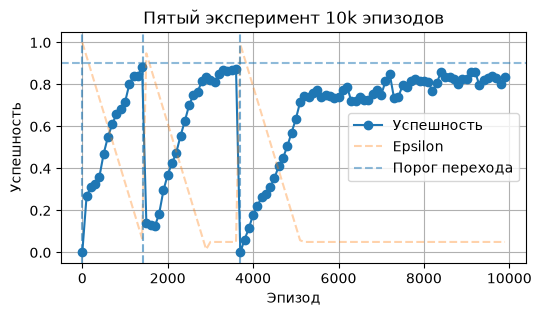

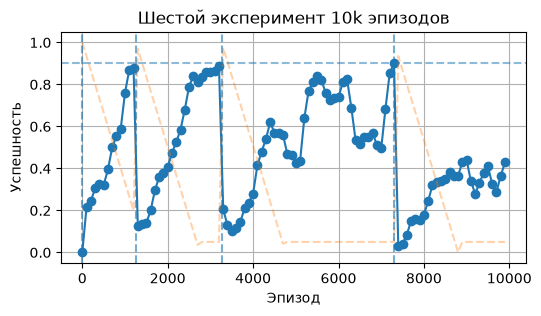

In [159]:
visualize(result_fifth_10k, title="Пятый эксперимент 10k эпизодов", success_threshold=0.9)
visualize(result_sixth_10k, title="Шестой эксперимент 10k эпизодов", success_threshold=0.9, legend=False)

На графиках видно, что пятый эксперимент ведет себя **более стабильно**, но в моменте замедляется и ходит под порогом перехода. Шестой же эксперимент ведет себя более резко, но благодаря этому и **пробивает порог перехода** и достигает **4 глубины**.

Думаю самое время **сравнить два лучших результата**, сделать выводы и совместить наработки:

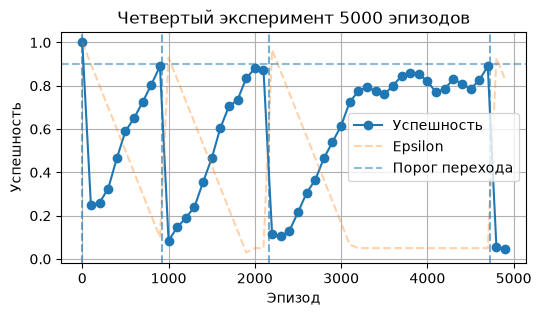

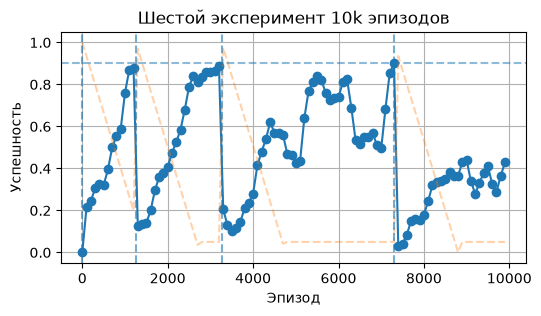

In [160]:
visualize(result_fourth_5000, title="Четвертый эксперимент 5000 эпизодов", success_threshold=0.9)
visualize(result_sixth_10k, title="Шестой эксперимент 10k эпизодов", success_threshold=0.9, legend=False)

В четвертом эксперименте мы разрешали делать до 40 ходов, а в шестом ограничились 20, но растянули ```eps_duration```. Оба привели нас к глубине 4, но четвертый эксперимент оказался эффективнее, т.к. мы пришли к этому результату всего за ~5 тысяч эпизодов, тогда как в шестом - за ~7 тысяч.

А также в обоих экспериментах формула была ```update_step = 800*max_steps/2```. Которую можно упростить до ```update_step = 400*max_steps```.

На основе этого можно попробовать провести эксперимент **аналогичный четвертому**, но с растянутым ```eps_duration``` как у **шестого**.

In [161]:
result_seventh = run_experiment(
    n_episodes=5000,
    max_steps=40,
    learning_rate=1e-4,
    update_step=400*40,
    success_threshold=0.9,
    eps_duration=1500,
    eps_rate=1
)

Максимум шагов: 40 
 Learning rate: 0.0001 
 Интервал обновления: 16000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Обновляем таргет, прошло: 579/5000 эпизодов, 240.51 сек
Обновляем таргет, прошло: 1446/5000 эпизодов, 470.44 сек
Обновляем таргет, прошло: 2114/5000 эпизодов, 702.43 сек
Обновляем таргет, прошло: 2973/5000 эпизодов, 940.34 сек
Обновляем таргет, прошло: 3530/5000 эпизодов, 1192.39 сек
Обновляем таргет, прошло: 4731/5000 эпизодов, 1465.33 сек
Время обучения: 1514.47 сек, достигнутая глубина: 3


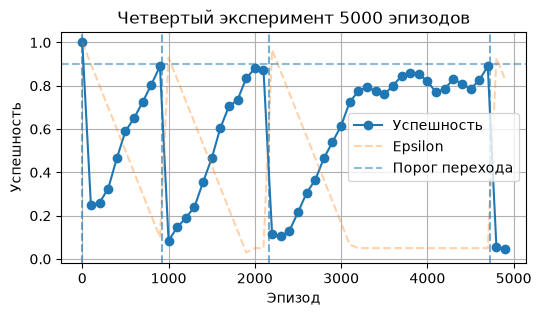

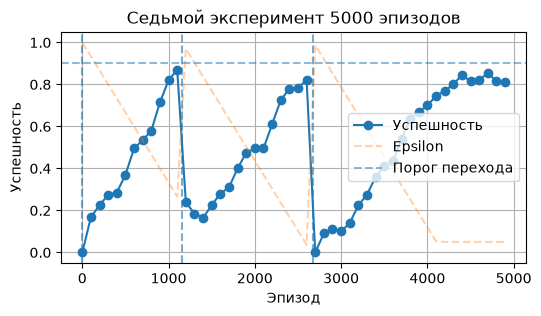

In [164]:
visualize(result_fourth_5000, title="Четвертый эксперимент 5000 эпизодов", success_threshold=0.9)
visualize(result_seventh, title="Седьмой эксперимент 5000 эпизодов", success_threshold=0.9, legend=False)

По итогу мы **растянули** график четвертого эксперимента. Стоит запустить оба эксперимента на 10 тысяч эпизодов и сравнить дает ли это растяжение какие-либо результаты на дистанции.

In [165]:
result_fourth_10k = run_experiment(
    n_episodes=10000,
    max_steps=40,
    learning_rate=1e-4,
    update_step=800*20,
    success_threshold=0.9,
    eps_duration=1000,
    eps_rate=1
)

Максимум шагов: 40 
 Learning rate: 0.0001 
 Интервал обновления: 16000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Обновляем таргет, прошло: 942/10000 эпизодов, 231.96 сек
Обновляем таргет, прошло: 1538/10000 эпизодов, 457.97 сек
Обновляем таргет, прошло: 3217/10000 эпизодов, 696.05 сек
Обновляем таргет, прошло: 3715/10000 эпизодов, 940.82 сек
Обновляем таргет, прошло: 4720/10000 эпизодов, 1188.34 сек
Обновляем таргет, прошло: 6520/10000 эпизодов, 1439.36 сек
Обновляем таргет, прошло: 7360/10000 эпизодов, 1689.79 сек
Обновляем таргет, прошло: 8071/10000 эпизодов, 1943.40 сек
Обновляем таргет, прошло: 9117/10000 эпизодов, 2217.05 сек
Обновляем таргет, прошло: 9977/10000 эпизодов, 2485.41 сек
Время обучения: 2491.02 сек, достигнутая глубина: 4


In [166]:
result_seventh_10k = run_experiment(
    n_episodes=10000,
    max_steps=40,
    learning_rate=1e-4,
    update_step=400*40,
    success_threshold=0.9,
    eps_duration=1500,
    eps_rate=1
)

Максимум шагов: 40 
 Learning rate: 0.0001 
 Интервал обновления: 16000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Обновляем таргет, прошло: 630/10000 эпизодов, 219.96 сек
Обновляем таргет, прошло: 1579/10000 эпизодов, 445.70 сек
Обновляем таргет, прошло: 2293/10000 эпизодов, 700.87 сек
Обновляем таргет, прошло: 3368/10000 эпизодов, 973.66 сек
Обновляем таргет, прошло: 3913/10000 эпизодов, 1236.20 сек
Обновляем таргет, прошло: 5218/10000 эпизодов, 1517.59 сек
Обновляем таргет, прошло: 6240/10000 эпизодов, 1866.42 сек
Обновляем таргет, прошло: 6715/10000 эпизодов, 2253.31 сек
Обновляем таргет, прошло: 7300/10000 эпизодов, 2560.66 сек
Обновляем таргет, прошло: 8023/10000 эпизодов, 2923.03 сек
Обновляем таргет, прошло: 8584/10000 эпизодов, 3281.71 сек
Обновляем таргет, прошло: 9190/10000 эпизодов, 3661.68 сек
Обновляем таргет, прошло: 9687/10000 эпизодов, 4023.58 сек
Время обучения: 4215.82 сек, достигнутая глубина: 4


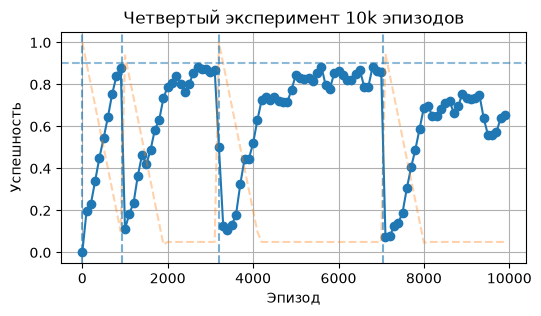

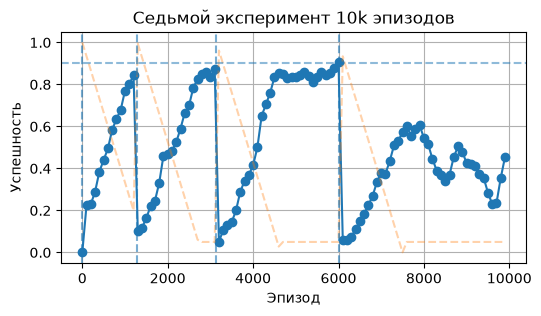

In [169]:
visualize(result_fourth_10k, title="Четвертый эксперимент 10k эпизодов", success_threshold=0.9, legend=False)
visualize(result_seventh_10k, title="Седьмой эксперимент 10k эпизодов", success_threshold=0.9, legend=False)

Вот здесь уже заметна **разница** между экспериментами: в седьмом мы **быстрее достигли 4 глубины**, но затем модель **не пробила даже 0.7**, а в четвертом мы чуть **позже достигли той же глубины** и далее более **процесс пошел более стабильно**, лишь **просев в конце**.

На этом этапе имеет смысл **зафиксировать результат и полученные модели**.

# Переход к дообучению

Если посмотреть на время, которое учились эти модели, то становится очевидно, что запускать каждый раз с нуля очень времязатратно, поэтому я решил написать новую функцию для **продолжения обучения** уже существующих моделей. Также **совмещать разные подходы** на разных этапах обучения может оказаться эффективнее

In [18]:
import copy

In [19]:
def continue_experiment(prev_result,n_episodes, max_steps, learning_rate, update_step, success_threshold, eps_duration=500, eps_rate=1.5):

    model = copy.deepcopy(prev_result["model"]).to(device)
    
    for param in model.parameters():
        param.requires_grad_(True)
    
    target_model = copy.deepcopy(prev_result["target_model"]).to(device)

    model.train()
    target_model.eval()
    
    replay_buffer = copy.deepcopy(prev_result["replay_buffer"])

    start_time = time.time()

    buffer_max_size = 500_000

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    scramble_depth = prev_result['final_depth']
    recent_results = []
    global_step = 0
    
    cubik = Cubik2()
    
    success_rate_stats = []
    depth_start_episode = [0]
    
    target_depth = 20
    
    print(
                "Максимум шагов:", max_steps, "\n",
                "Learning rate:", learning_rate, "\n",
                "Интервал обновления:", update_step, "\n",
                "Макс. размер буффера:", buffer_max_size, "\n",
                "Целевая глубина:", target_depth
            )
    
    local_episode = 0
    
    for episode in range(n_episodes):
        if local_episode < eps_duration:
            eps = (1-(local_episode/eps_duration))/eps_rate
        else:
            eps = 0.05
    
        episode_depth = pick_depth(scramble_depth)

        episode_max_steps = min(max_steps, 2*episode_depth+4)
        
        solved, steps, loss = run_episode(
            cubik,
            model,
            target_model,
            optimizer,
            replay_buffer,
            episode_depth,
            eps,
            episode_max_steps
        )
    
        global_step += steps
        local_episode += 1
    
        recent_results.append(int(solved))
    
        if len(recent_results) > 200:
            recent_results.pop(0)
    
        if (global_step % update_step < steps): # обновляемся ~ каждые update_step шагов (не придумал как лучше считать)
            elapsed_time = time.time() - start_time
            print(f"Обновляем таргет, прошло: {episode}/{n_episodes} эпизодов, {elapsed_time:.2f} сек")
            target_model.load_state_dict(model.state_dict())
    
        if len(replay_buffer) > buffer_max_size + 5000:
            replay_buffer = replay_buffer[-buffer_max_size:]
    

        success_rate = (sum(recent_results)/max(1, len(recent_results)))
        
        if (len(recent_results) == 200 and sum(recent_results)/200 > success_threshold):
            scramble_depth += 1
            recent_results.clear()
            local_episode = 0
            depth_start_episode.append(episode)
            if scramble_depth == target_depth+1:
                print("Достигнута целевая глубина:", target_depth)
                break
        
    
        if episode % 100 == 0:
            success_rate_stats.append([success_rate,eps,scramble_depth,len(replay_buffer)])
    
    elapsed_time = time.time() - start_time
    print(f"Время обучения: {elapsed_time:.2f} сек, достигнутая глубина: {scramble_depth}")

    return {
        "model": model,
        "target_model": target_model,
        "replay_buffer": replay_buffer,
        "final_depth": scramble_depth,
        "stats": success_rate_stats,
        "depth_start_episode": depth_start_episode,
    }

Почему-то отключился autograd.

In [192]:
torch.set_grad_enabled(True)

С этого момента каждую модель я буду сохранять и подгружать, чтобы эксперименты ниже были воспроизводимы. К сожалению с экспериментами выше так сделать я не догадался. Выше я сохранил только веса, но, как оказалось, другие параметры тоже важно было сохранить. Поэтому напишем функции сохранения и загрузки.

In [22]:
def save_result(result, filename):
    checkpoint = {
        "model_state_dict": result["model"].state_dict(),
        "target_model_state_dict": result["target_model"].state_dict(),
        "replay_buffer": result["replay_buffer"],
        "final_depth": result["final_depth"],
        "stats": result["stats"],
        "depth_start_episode": result["depth_start_episode"],
    }

    torch.save(checkpoint, filename)

    print(f"Результат сохранен в: {filename}")
    print(f"Глубина: {result['final_depth']}")

In [23]:
def load_result(filename, device):
    checkpoint = torch.load(filename, map_location="cpu", weights_only=False)

    model = DQN()
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)


    target_model = DQN()
    target_model.load_state_dict(checkpoint["target_model_state_dict"])
    target_model = target_model.to(device)

    model.train()
    target_model.eval()

    result = {
        "model": model,
        "target_model": target_model,
        "replay_buffer": checkpoint["replay_buffer"],
        "final_depth": checkpoint["final_depth"],
        "stats": checkpoint["stats"],
        "depth_start_episode": checkpoint["depth_start_episode"],
    }

    print(f"Результат загружен из: {filename}")
    print(f"Глубина: {result['final_depth']}")
    print(f"Размер replay buffer: {len(result['replay_buffer'])}")

    return result

In [24]:
def result_from_weights(
    model_path,
    target_model_path,
    device,
    final_depth=4
):
    model = DQN().to(device)
    target_model = DQN().to(device)

    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))

    target_model.load_state_dict(torch.load(target_model_path, map_location=device, weights_only=True))

    model.train()

    target_model.eval()

    result = {
        "model": model,
        "target_model": target_model,

        # Старый replay buffer не сохранился(
        "replay_buffer": [],
        "final_depth": final_depth,

        # Старая статистика тоже(
        "stats": [],
        "depth_start_episode": [0],
    }

    print("Веса успешно загружены")
    print("model:", model_path)
    print("target_model:", target_model_path)
    print("final_depth:", final_depth)

    return result

Перед запуском я решил снизить начальный ```eps``` и попробовать сделать ```learning_rate``` ниже. Теперь мы работаем с уже обученной моделью, поэтому важно по-немногу двигать веса относительно текущего неплохого результата (возможно именно поэтому мы упирались в потолок).

Но перед этим объясню **нововведение**, которое я ввел в функцию продолжения (в отличие от функции обучения с нуля):

```episode_max_steps = min(max_steps, 2*episode_depth+4)```

Чтобы ускорить процесс обучения, я решил автоматически считать ```episode_max_steps``` под каждый эпизод, ну и на всякий случай ограничиться тем значением, которое я скормлю. Что же выйдет на практике сейчас увидим.

In [32]:
result_fourth_10k_loaded = result_from_weights(model_path="model_4_10k.pth",
    target_model_path="model_4_10k_target.pth",
    device=device,
    final_depth=1
)

Веса успешно загружены
model: model_4_10k.pth
target_model: model_4_10k_target.pth
final_depth: 1


Так как я забыл сохранить буфер, я задал глубину 1, чтобы заодно набрать данных для буфера.

In [41]:
result_fourth_10k_continue = continue_experiment(
    prev_result=result_fourth_10k_loaded,
    n_episodes=20000,
    max_steps=20,
    learning_rate=1e-4,
    update_step=400*20,
    success_threshold=0.9,
    eps_duration=500,
    eps_rate=2
)

Максимум шагов: 20 
 Learning rate: 0.0001 
 Интервал обновления: 8000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Обновляем таргет, прошло: 3325/20000 эпизодов, 102.35 сек
Обновляем таргет, прошло: 5078/20000 эпизодов, 205.91 сек
Обновляем таргет, прошло: 6723/20000 эпизодов, 311.04 сек
Обновляем таргет, прошло: 8117/20000 эпизодов, 411.76 сек
Обновляем таргет, прошло: 9491/20000 эпизодов, 510.11 сек
Обновляем таргет, прошло: 10889/20000 эпизодов, 611.25 сек
Обновляем таргет, прошло: 12240/20000 эпизодов, 713.66 сек
Обновляем таргет, прошло: 13606/20000 эпизодов, 819.29 сек
Обновляем таргет, прошло: 15191/20000 эпизодов, 926.13 сек
Обновляем таргет, прошло: 17309/20000 эпизодов, 1034.74 сек
Время обучения: 1145.71 сек, достигнутая глубина: 1


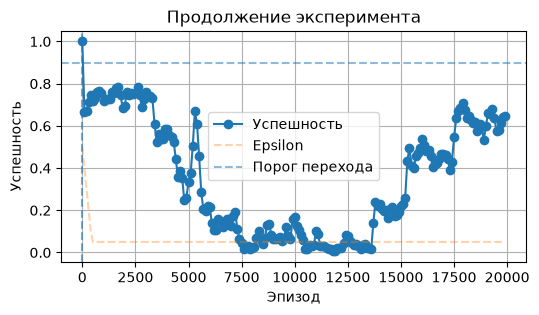

In [42]:
visualize(result_fourth_10k_continue, title="Продолжение эксперимента", success_threshold=0.9)

И нейросеть не смогла достигнуть даже 1 глубины, хотя мы поставили ее на дообучение и ранее она уже умела хорошо решать такие кубики. К этому моменту **ушло достаточно много ресурсов** и **получилось несопоставимо мало результата**. Так что я решил провести пару контрольных экспериментов и, в случае неудачи, все-таки заметно **изменить подход к обучению**.

Для начала я решил дать модели больше эпизодов, а также более плавную смену весов (уменьшил ```learning rate```). Остальные настройки я взял основываясь на предыдущем опыте, а также уменьшил начальную вероятность случайных ходов, чтобы заодно проверить как это сказывается на обучении.

In [44]:
result_8th = run_experiment(
    n_episodes=20000,
    max_steps=30,
    learning_rate=1e-5,
    update_step=800*30,
    success_threshold=0.9,
    eps_duration=1000,
    eps_rate=2
)

Максимум шагов: 30 
 Learning rate: 1e-05 
 Интервал обновления: 24000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Обновляем таргет, прошло: 2148/20000 эпизодов, 345.80 сек
Обновляем таргет, прошло: 4081/20000 эпизодов, 679.61 сек
Обновляем таргет, прошло: 6164/20000 эпизодов, 1027.37 сек
Обновляем таргет, прошло: 8477/20000 эпизодов, 1390.94 сек
Обновляем таргет, прошло: 10862/20000 эпизодов, 1750.36 сек
Обновляем таргет, прошло: 13590/20000 эпизодов, 2094.08 сек
Обновляем таргет, прошло: 16066/20000 эпизодов, 2441.58 сек
Обновляем таргет, прошло: 19230/20000 эпизодов, 2815.81 сек
Время обучения: 3002.80 сек, достигнутая глубина: 3


In [45]:
save_result(result_8th, "result_8th.pth")

Результат сохранен в: result_8th.pth
Глубина: 3


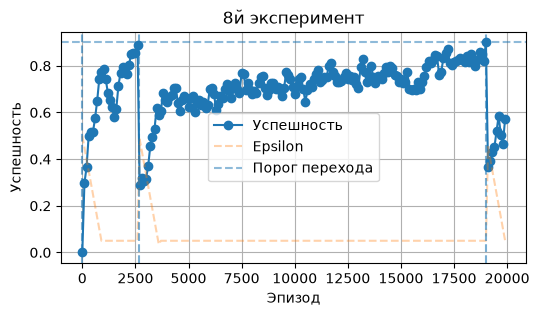

In [46]:
visualize(result_8th, title="8й эксперимент", success_threshold=0.9)

Пока получился достаточно ожидаемый результат. График стал менее гладким и модели потребовалось больше времени в эпизодах на обучение, так как веса менялись медленнее.

Далее я попробовал снизить порог перехода глубины, поиграться с ```update_step``` и ```eps_duration```.

In [47]:
result_8th_continue = continue_experiment(
    prev_result=result_8th,
    n_episodes=100000,
    max_steps=20,
    learning_rate=1e-5,
    update_step=500*20,
    success_threshold=0.87,
    eps_duration=500,
    eps_rate=2
)

Максимум шагов: 20 
 Learning rate: 1e-05 
 Интервал обновления: 10000 
 Макс. размер буффера: 500000 
 Целевая глубина: 20
Обновляем таргет, прошло: 1914/100000 эпизодов, 160.76 сек
Обновляем таргет, прошло: 3974/100000 эпизодов, 313.97 сек
Обновляем таргет, прошло: 5796/100000 эпизодов, 460.06 сек
Обновляем таргет, прошло: 7827/100000 эпизодов, 603.23 сек
Обновляем таргет, прошло: 9872/100000 эпизодов, 749.99 сек
Обновляем таргет, прошло: 11943/100000 эпизодов, 864.98 сек
Обновляем таргет, прошло: 14096/100000 эпизодов, 980.33 сек
Обновляем таргет, прошло: 16253/100000 эпизодов, 1097.22 сек
Обновляем таргет, прошло: 18432/100000 эпизодов, 1214.23 сек
Обновляем таргет, прошло: 20637/100000 эпизодов, 1331.57 сек
Обновляем таргет, прошло: 22763/100000 эпизодов, 1450.13 сек
Обновляем таргет, прошло: 24882/100000 эпизодов, 1568.95 сек
Обновляем таргет, прошло: 27037/100000 эпизодов, 1688.25 сек
Обновляем таргет, прошло: 29250/100000 эпизодов, 1807.47 сек
Обновляем таргет, прошло: 31394/10

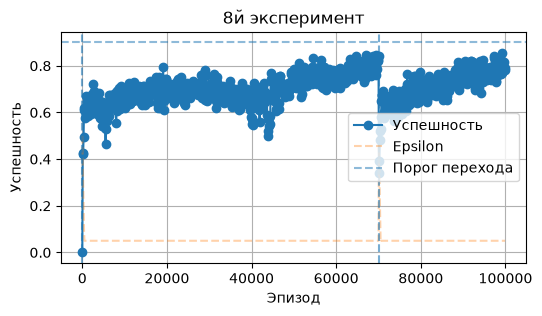

In [48]:
visualize(result_8th_continue, title="8й эксперимент", success_threshold=0.9)

In [49]:
save_result(result_8th_continue, "result_8th_continue.pth")

Результат сохранен в: result_8th_continue.pth
Глубина: 4


Оглядываясь назад, на самом деле нужно было увеличить ```eps_duration```, т.к. веса меняются медленнее и модели нужно дать больше времени на исследования.

Итого **за 100,000 эпизодов** дообучения мы лишь **достигли 4 глубины**, что говорит об **очень плохой эффективности подхода**.

К этому моменту я уже **перепробовал достаточно много вариантов**, часть из которых осталась все этого файла и, к сожалению, вряд-ли тут появятся. И с каждым разом обучение текущей модели текущим способом **не давало весомых результатов**. Конечно, можно приложить еще некоторые усилия и упорство, но тогда общий КПД упадет и я закончу этот проект лишь спустя месяц, а то и больше.

### Резюмируя проделанный выше результат:

Обучать модель по принципу "нашел решение - молодец, не нашел - ищи дальше" без какого-либо сопровождения оказалось достаточно сложным процессом для получения хотя-бы минимального видимого результата. Не отрицаю, что, вероятно, найдутся более опытные люди, которым хватит 5-10 минут, чтобы подобрать параметры и довести идею до конца и даже уложиться в ограничение по вычислительным мощностям. Но на момент написания этого проекта я обладаю ограниченными познаниями. Возможно, если все-таки увижу потенциал завершить то, что пытался выше, то вернусь и дополню этот блокнот. Но сейчас пора перейти к **перестройке структуры обучения**.

In [3]:
# TODO: написать обучение с явной наградой за приближение к собранному кубику